In [ ]:
import zipfile
import os

In [ ]:
safe_zip = "/content/drive/MyDrive/QR_All_benign.zip"
phish_zip = "/content/drive/MyDrive/QR_All_Malicious.zip"
extract_path = "/content/qr_dataset/"

In [ ]:
os.makedirs(extract_path, exist_ok=True)

for zip_file in [safe_zip, phish_zip]:
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

In [4]:
import os
import random
import shutil

base_path = "/content/qr_dataset"

malicious_path = os.path.join(base_path, "/content/qr_dataset/QR_All_Malicious", "/content/qr_dataset/QR_All_Malicious/qrs")
benign_path = os.path.join(base_path, "/content/qr_dataset/QR_All_benign", "/content/qr_dataset/QR_All_benign/qrs")


subset_path = "/content/qr_subset"
mal_subset = os.path.join(subset_path, "malicious")
ben_subset = os.path.join(subset_path, "benign")

os.makedirs(mal_subset, exist_ok=True)
os.makedirs(ben_subset, exist_ok=True)

fraction = 0.05

def create_subset(src, dst, frac):
    images = os.listdir(src)
    sample_size = int(len(images) * frac)

    selected = random.sample(images, sample_size)

    for img in selected:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(dst, img)
        )


create_subset(malicious_path, mal_subset, fraction)
create_subset(benign_path, ben_subset, fraction)

print("Subset created!")

Subset created!


In [5]:
print("Malicious:", len(os.listdir(mal_subset)))
print("Benign:", len(os.listdir(ben_subset)))
print("Total:", len(os.listdir(mal_subset)) + len(os.listdir(ben_subset)))

Malicious: 28788
Benign: 21498
Total: 50286


In [6]:
!pip install opencv-python pyzbar pandas numpy scikit-learn xgboost

In [7]:
import cv2

def detect_and_decode_qr(image_path):
    detector = cv2.QRCodeDetector()
    img = cv2.imread(image_path)

    data, points, _ = detector.detectAndDecode(img)

    if points is not None and data:
        return data
    else:
        return None

In [8]:
import os
import pandas as pd

base_folder = "/content/qr_subset"

benign_folder = os.path.join(base_folder, "/content/qr_subset/benign")
malicious_folder = os.path.join(base_folder, "/content/qr_subset/malicious")

records = []

# benign images
for img in os.listdir(benign_folder):
    if img.lower().endswith(('.png','.jpg','.jpeg')):
        path = os.path.join(benign_folder, img)
        url = detect_and_decode_qr(path)

        if url:
            records.append({
                "image": img,
                "url": url,
                "label": "safe"
            })

# malicious images
for img in os.listdir(malicious_folder):
    if img.lower().endswith(('.png','.jpg','.jpeg')):
        path = os.path.join(malicious_folder, img)
        url = detect_and_decode_qr(path)

        if url:
            records.append({
                "image": img,
                "url": url,
                "label": "phishing"
            })

df = pd.DataFrame(records)

df.to_csv("qr_results.csv", index=False)

df.head()

,image,url,label
0,benign_154812.png,reviews.cnet.com/televisions/,safe
1,benign_160137.png,smithvilletimes.com/2011/08/09/carolina-carole...,safe
2,benign_205044.png,associatepublisher.com/e/j/ji/,safe
3,benign_207384.png,barbaraling.com/knowledge-center/Breyer_stable...,safe
4,benign_023615.png,docbook.org/tdg/,safe


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

In [10]:
import numpy as np
from urllib.parse import urlparse
import ipaddress
import math
import re

def entropy(s):
    if not s:
        return 0
    prob = [s.count(c)/len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in prob)

def is_valid_domain(domain):
    if not domain:
        return False
    pattern = r"^[a-zA-Z0-9.-]+$"
    return re.match(pattern, domain) is not None

def extract_features(url):
    try:
        parsed = urlparse(str(url))
        domain = parsed.netloc
        path = parsed.path

        # Check if domain is IP
        try:
            ipaddress.ip_address(domain)
            have_ip = 1
        except:
            have_ip = 0

        features = [
            len(url),
            len(domain),
            url.count('.'),
            path.count('/'),
            1 if '@' in url else 0,
            1 if '-' in domain else 0,
            1 if parsed.scheme == "https" else 0,
            entropy(url)
        ]

        return features

    except Exception:
        return [0]*8   # safe fallback
url_features = np.array([extract_features(u) for u in df['url']])

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(analyzer='char', ngram_range=(2,5))
tfidf_features = tfidf.fit_transform(df['url'])

In [12]:
from scipy.sparse import hstack

X = hstack([tfidf_features, url_features])
y = df['label_encoded'].values

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, pred)*100)
print(classification_report(y_val, pred, target_names=["phishing","safe"]))

Accuracy: 96.18554522400676
              precision    recall  f1-score   support

    phishing       0.98      0.95      0.97      5308
        safe       0.94      0.97      0.96      4156

    accuracy                           0.96      9464
   macro avg       0.96      0.96      0.96      9464
weighted avg       0.96      0.96      0.96      9464



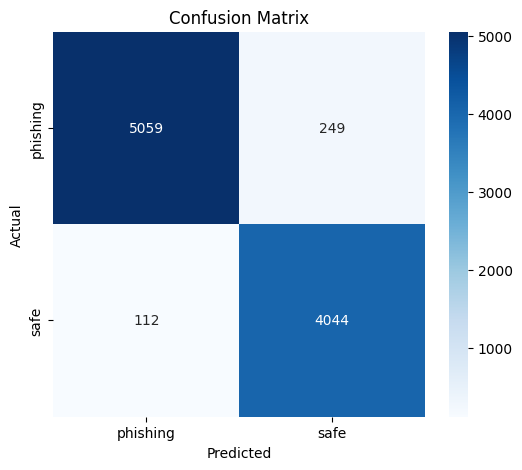

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, pred)
labels = ['phishing','safe']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

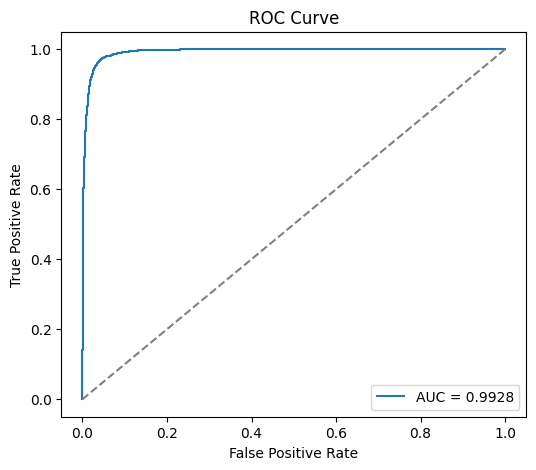

In [16]:
from sklearn.metrics import roc_curve, auc

y_score = model.predict_proba(X_val)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],"--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [17]:
model.save_model("َQR_Code_xgboost_model.json")

In [18]:
import joblib

joblib.dump(model, "QR_Code_xgboost_model.pkl")

['QR_Code_xgboost_model.pkl']

In [20]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [21]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [22]:
import json

config = {
    "model_type": "XGBoost",
    "ngram_range": [2,5],
    "threshold": 0.5
}

with open("config.json", "w") as f:
    json.dump(config, f, indent=4)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, pred)
precision = precision_score(y_val, pred, average='weighted')
recall = recall_score(y_val, pred, average='weighted')
f1 = f1_score(y_val, pred, average='weighted')

metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1
}

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)